<h3 style="font-size:17px; font-weight:bold;">Regresia Logistică</h3>

<h5 style="font-size:14px;">

**Definiție:** Regresia logistică este o metodă statistică utilizată pentru probleme de clasificare, în special pentru clasificare binară. Ea modelează probabilitatea ca o observație să aparțină unei clase folosind funcția logistică (sigmoidă). Deși se numește „regresie”, este folosită în principal pentru clasificare.  

**Tipuri:**<br>
- **Regresie logistică binară:** clasifică datele în două clase (ex: 0 și 1).<br>
- **Regresie logistică multinomială:** utilizată pentru clasificare multiclasă (mai mult de două clase).<br>
- **Regresie logistică ordinală:** utilizată când variabila dependentă are categorii ordonate.<br>

**Elemente teoretice:**<br>
- **Funcția sigmoidă (logistică):** transformă rezultatul liniar într-o probabilitate între 0 și 1.<br>
- **z = β₀ + β₁X₁ + ... + βₚXₚ:** combinația liniară a variabilelor independente.<br>
- **β (coeficienți):** indică influența fiecărei variabile asupra log-odds-ului.<br>
- **Log-odds (logit):** log(p / (1 - p)), unde p este probabilitatea clasei 1.<br>
- **p (probabilitate estimată):** șansa ca observația să aparțină clasei pozitive.<br>

**Presupuneri ale regresiei logistice:**<br>
- Relația dintre variabilele independente și log-odds este liniară.<br>
- Observațiile sunt independente.<br>
- Nu există multicoliniaritate puternică între variabile.<br>
- Dimensiunea eșantionului este suficient de mare.<br><br>

</h5>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
passengers = pd.read_csv("../data/titanic_survival.csv")

<h5 style="font-size:14px;">

**Descrierea setului de date:** Setul de date *Titanic* conține informații despre pasagerii care se aflau la bordul navei Titanic, inclusiv caracteristici demografice și informații despre bilete. Datele sunt folosite pentru analiza supraviețuirii pasagerilor în urma tragediei.

**Structura datelor:**<br>
- **PassengerId:** identificator unic al pasagerului.<br>
- **Survived:** indică dacă pasagerul a supraviețuit (1 = da, 0 = nu).<br>
- **Pclass:** clasa pasagerului (1 = întâi, 2 = a doua, 3 = a treia).<br>
- **Name:** numele complet al pasagerului.<br>
- **Sex:** genul pasagerului (male/female).<br>
- **Age:** vârsta pasagerului (în ani).<br>
- **SibSp:** numărul de frați sau soți/soții aflați la bord.<br>
- **Parch:** numărul de părinți sau copii aflați la bord.<br>
- **Ticket:** numărul biletului.<br>
- **Fare:** prețul biletului.<br>
- **Cabin:** cabina atribuită pasagerului (dacă există).<br>
- **Embarked:** portul de îmbarcare (C = Cherbourg, Q = Queenstown, S = Southampton).<br>

**Variabile numerice utilizate în analiză:**<br>
- **Age** – vârsta pasagerului.<br>
- **SibSp** – numărul de frați/soți.<br>
- **Parch** – numărul de părinți/copii.<br>
- **Fare** – prețul biletului.<br>

**Observație:** În cadrul analizelor statistice și modelării supraviețuirii (ex. regresie logistică) vor fi utilizate variabilele numerice și categorice relevante, precum clasa, sexul și prețul biletului, pentru a estima probabilitatea ca un pasager să supraviețuiască.

</h5>

In [3]:
passengers.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
passengers.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [5]:
passengers.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [6]:
passengers.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
passengers.shape

(891, 12)

In [8]:
passengers.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [9]:
passengers.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [10]:
passengers.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
passengers.duplicated().sum()

np.int64(0)

In [12]:
passengers.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

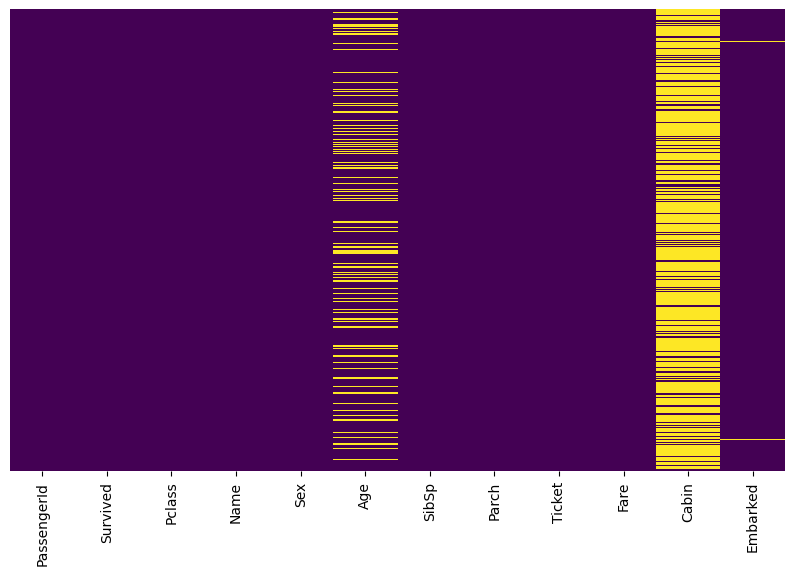

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(passengers.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

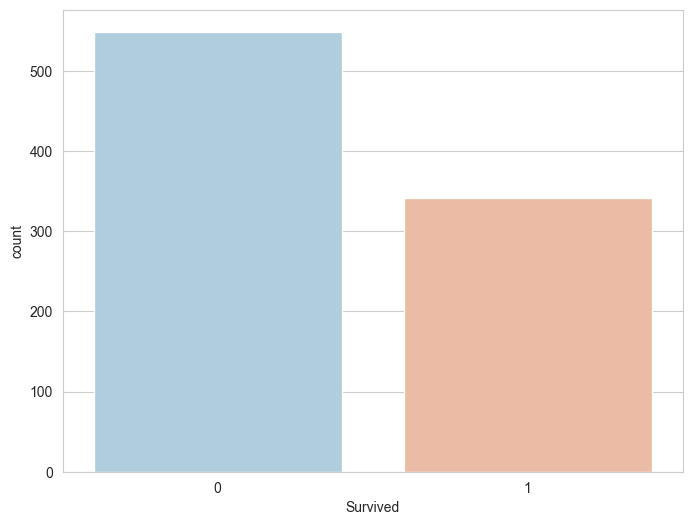

In [14]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', hue='Survived', data=passengers, palette='RdBu_r', legend=False)
plt.show()

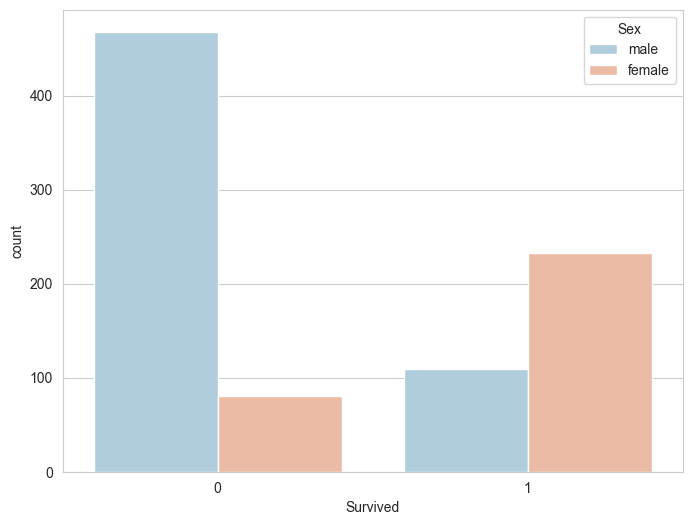

In [15]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', hue='Sex', data=passengers, palette='RdBu_r')
plt.show()

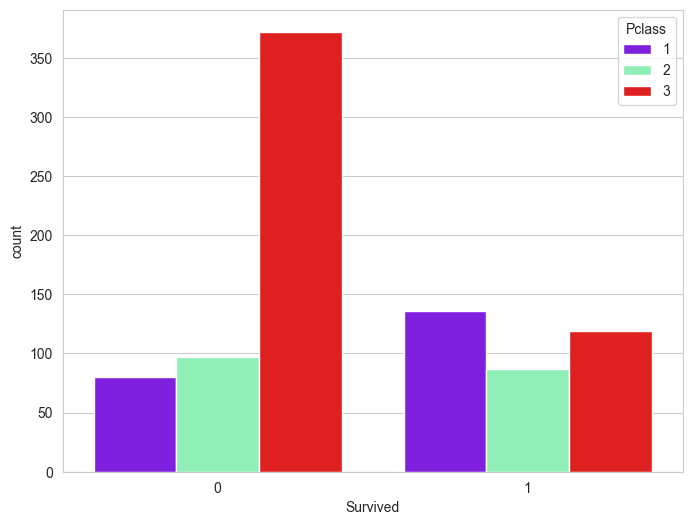

In [16]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.countplot(x='Survived', hue='Pclass', data=passengers, palette='rainbow')
plt.show()

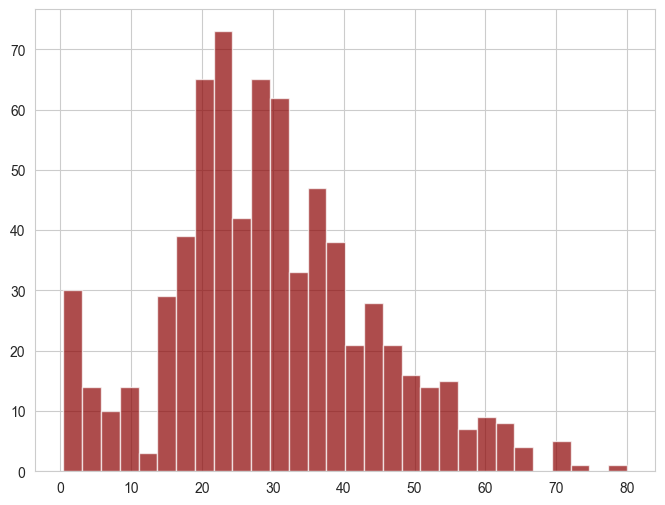

In [17]:
plt.figure(figsize=(8, 6))
passengers['Age'].hist(bins=30, color='darkred', alpha=0.7)
plt.show()

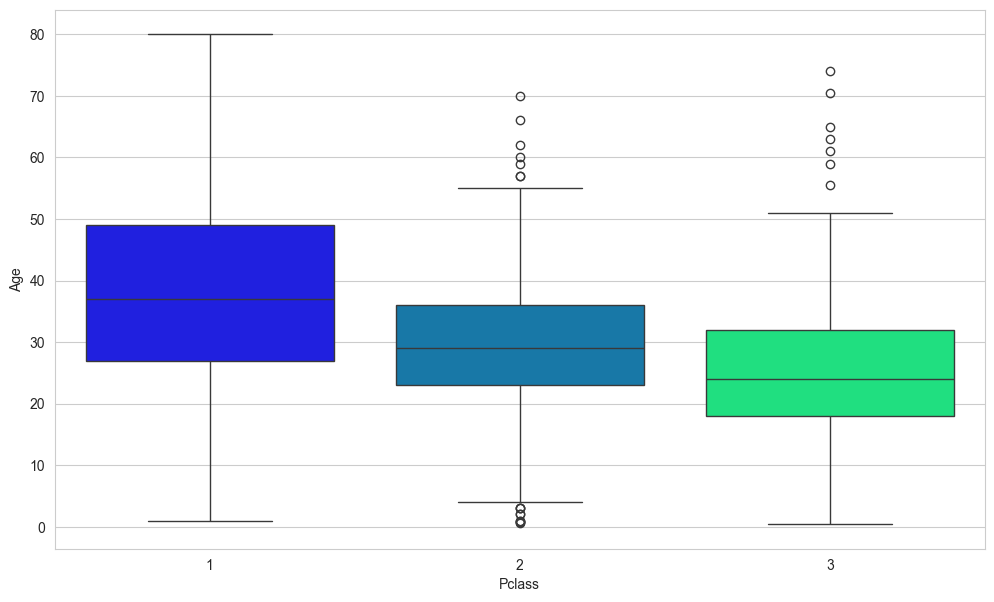

In [18]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', hue='Pclass', data=passengers, palette='winter', legend=False)
plt.show()

In [19]:
def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    return Age

In [20]:
passengers['Age'] = passengers[['Age', 'Pclass']].apply(impute_age, axis=1)

In [21]:
passengers.drop('Cabin', axis=1, inplace=True)

In [22]:
passengers.dropna(inplace=True)

In [23]:
sex = pd.get_dummies(passengers['Sex'], drop_first=True).astype('uint8')
embark = pd.get_dummies(passengers['Embarked'], drop_first=True).astype('uint8')

In [24]:
passengers.drop(['Sex','Embarked','Name','Ticket'], axis=1, inplace=True)
passengers = pd.concat([passengers, sex, embark], axis=1)

In [25]:
x_train, x_test, y_train, y_test = train_test_split(passengers.drop('Survived', axis=1), passengers['Survived'], test_size=0.30, random_state=101)

In [26]:
print("Training set size:", x_train.shape)
print("Test set size:", x_test.shape)

Training set size: (622, 9)
Test set size: (267, 9)


In [27]:
logmodel = LogisticRegression(max_iter=1000)

logmodel.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [28]:
predictions = logmodel.predict(x_test)

In [29]:
confusion_matrix(y_test, predictions)

array([[149,  14],
       [ 33,  71]])

In [30]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.82      0.82       267



<h5 style="font-size:14px;">

**Interpretarea coeficienților:** Coeficienții obținuți din regresia logistică arată cât de mult influențează fiecare variabilă șansa de supraviețuire a pasagerilor. De exemplu, coeficientul pentru **sex** (0 = female, 1 = male) este negativ, indicând că bărbații au o probabilitate mai mică de supraviețuire comparativ cu femeile. **Pclass** are, de asemenea, un efect negativ pentru clasele inferioare (clasa 3), ceea ce sugerează că pasagerii din clasa 1 au cele mai mari șanse de supraviețuire. Variabilele **SibSp** și **Parch** (numărul de frați/căsători și părinți/copii la bord) au coeficienți mici, indicând un impact redus asupra șanselor de supraviețuire. **Prețul biletului (Fare)** are un efect pozitiv mic, sugerând că pasagerii care au plătit mai mult pentru bilet au avut o probabilitate puțin mai mare de supraviețuire.<br><br>

**Recomandare:** În funcție de aceste rezultate, pentru o analiză predictivă a supraviețuirii, modelul sugerează că **sexul** și **clasa pasagerului** sunt cele mai puternice variabile de luat în considerare. Alte variabile, precum numărul de frați/copii sau părinți/copii și prețul biletului, au impact redus, deci pot fi folosite, dar nu vor schimba semnificativ predicțiile. Pentru îmbunătățirea modelului, se poate încerca includerea informațiilor suplimentare extrase din **Name** (ex. titluri: Dl., D-na, D-ra) sau păstrarea anumitor caracteristici din **Ticket**, astfel încât să se obțină predicții mai precise.

</h5>